In [1]:
import heapq
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [2]:
from utils import (
    format_menu,
    input_parser,
    available_assignments,
    day_menu_cost,
    InputData,
    Schedule,
)

In [3]:
sample_input = """% Comments
% Cost <food-item> <value>
C TC 1
C DF 1
C PM 1
C GJ 1
% Group size
G 2
% Inputs - books / notes. It ends with -1
I 1 2 3 4 5 6 -1
% Outputs - final outcome. It ends with -1
O 13 14 17 -1
% Assignment dependency list
% A <id> <input1> <input2> <outcome> <Food-name>
A 1 1 3 7 TC
A 2 4 2 8 TC
A 3 1 3 9 TC
A 4 2 3 10 PM
A 5 7 8 11 TC
A 6 4 6 12 TC
A 7 6 9 13 PM
A 8 10 5 14 GJ
A 9 1 11 15 DF
A 10 3 12 16 TC
A 11 15 16 17 DF"""

input_data = input_parser(sample_input)
input_data

{'food_cost': {'TC': 1, 'DF': 1, 'PM': 1, 'GJ': 1},
 'group_size': 2,
 'initial_inputs': {1, 2, 3, 4, 5, 6},
 'outputs': {13, 14, 17},
 'assignments': {1: {'id': 1, 'prereqs': (1, 3), 'outcome': 7, 'food': 'TC'},
  2: {'id': 2, 'prereqs': (4, 2), 'outcome': 8, 'food': 'TC'},
  3: {'id': 3, 'prereqs': (1, 3), 'outcome': 9, 'food': 'TC'},
  4: {'id': 4, 'prereqs': (2, 3), 'outcome': 10, 'food': 'PM'},
  5: {'id': 5, 'prereqs': (7, 8), 'outcome': 11, 'food': 'TC'},
  6: {'id': 6, 'prereqs': (4, 6), 'outcome': 12, 'food': 'TC'},
  7: {'id': 7, 'prereqs': (6, 9), 'outcome': 13, 'food': 'PM'},
  8: {'id': 8, 'prereqs': (10, 5), 'outcome': 14, 'food': 'GJ'},
  9: {'id': 9, 'prereqs': (1, 11), 'outcome': 15, 'food': 'DF'},
  10: {'id': 10, 'prereqs': (3, 12), 'outcome': 16, 'food': 'TC'},
  11: {'id': 11, 'prereqs': (15, 16), 'outcome': 17, 'food': 'DF'}}}

In [4]:
def generate_day_choices(avail: list[int], g: int) -> list[tuple[int, ...]]:
    choices: list[tuple[int, ...]] = []
    max_size = min(g, len(avail))
    for r in range(1, max_size + 1):
        for combo in combinations(avail, r):
            choices.append(tuple(sorted(combo)))
    return choices

In [5]:
def heuristic(data: InputData, completed: frozenset[int]) -> int:
    remaining = len(data["assignments"]) - len(completed)
    min_food_cost = min(data["food_cost"].values())
    return remaining * min_food_cost


def apply_day(
    data: InputData,
    completed: frozenset[int],
    available_resources: frozenset[int],
    chosen: tuple[int, ...],
) -> tuple[frozenset[int], frozenset[int], dict[str, int], int]:
    new_completed = set(completed)
    new_resources = set(available_resources)

    for aid in chosen:
        new_completed.add(aid)
        new_resources.add(data["assignments"][aid]["outcome"])

    menu_counter, cost_today = day_menu_cost(chosen, data)
    return frozenset(new_completed), frozenset(new_resources), menu_counter, cost_today

In [6]:
def astar_optimal_schedule(data: InputData) -> tuple[list[Schedule], int, int, int]:
    assignments = data["assignments"]
    start_completed: frozenset[int] = frozenset()
    start_resources: frozenset[int] = frozenset(data["initial_inputs"])

    start_g = 0
    start_h = heuristic(data, start_completed)
    start_f = start_g + start_h

    pq: list[
        tuple[int, int, int, int, frozenset[int], frozenset[int], list[Schedule]]
    ] = []
    state_id = 0

    heapq.heappush(
        pq, (start_f, start_g, 0, state_id, start_completed, start_resources, [])
    )

    best_cost = {}
    best_cost[(start_completed, start_resources)] = 0

    states_explored = 0

    while pq:
        _f_val, g_val, days_used, _, completed, resources, schedule = heapq.heappop(pq)
        states_explored += 1

        if len(completed) == len(assignments):
            return schedule, days_used, g_val, states_explored

        avail = available_assignments(data, completed, resources)

        if not avail:
            continue

        day_choices = generate_day_choices(avail, data["group_size"])

        for chosen in day_choices:
            new_completed, new_resources, menu_counter, cost_today = apply_day(
                data, completed, resources, chosen
            )

            new_g = g_val + cost_today
            new_h = heuristic(data, new_completed)
            new_f = new_g + new_h
            new_days = days_used + 1

            state_key = (new_completed, new_resources)

            if state_key not in best_cost or new_g < best_cost[state_key]:
                best_cost[state_key] = new_g
                state_id += 1

                new_schedule = schedule + [
                    Schedule(
                        day=new_days,
                        assignments=list(chosen),
                        menu=menu_counter,
                        cost=cost_today,
                    )
                ]

                heapq.heappush(
                    pq,
                    (
                        new_f,
                        new_g,
                        new_days,
                        state_id,
                        new_completed,
                        new_resources,
                        new_schedule,
                    ),
                )

    raise RuntimeError("Something went wrong.")


astar_schedule, astar_total_days, astar_total_cost, astar_states_explored = (
    astar_optimal_schedule(input_data)
)

print("total_days:", astar_total_days)
print("total_cost:", astar_total_cost)
print("states_explored:", astar_states_explored)
print("schedule:")
astar_schedule

total_days: 6
total_cost: 11
states_explored: 171
schedule:


[{'day': 1, 'assignments': [1], 'menu': {'TC': 1}, 'cost': 1},
 {'day': 2, 'assignments': [2, 3], 'menu': {'TC': 2}, 'cost': 2},
 {'day': 3, 'assignments': [4, 5], 'menu': {'PM': 1, 'TC': 1}, 'cost': 2},
 {'day': 4, 'assignments': [6, 7], 'menu': {'TC': 1, 'PM': 1}, 'cost': 2},
 {'day': 5, 'assignments': [9, 10], 'menu': {'DF': 1, 'TC': 1}, 'cost': 2},
 {'day': 6, 'assignments': [8, 11], 'menu': {'GJ': 1, 'DF': 1}, 'cost': 2}]

In [7]:
def print_astar_result(
    schedule: list[Schedule], total_days: int, total_cost: int, states_explored: int
):
    print("Optimal Schedule using A* Search")
    print("-" * 60)

    for entry in schedule:
        day = entry["day"]
        tasks = ", ".join(f"A{x}" for x in entry["assignments"])
        menu = format_menu(entry["menu"])
        print(f"Day-{day}: {tasks}    Menu: {menu}    Cost: {entry['cost']}")

    print("-" * 60)
    print(f"Total Days: {total_days}")
    print(f"Total Cost: {total_cost}")
    print(f"States Explored: {states_explored}")


print_astar_result(
    astar_schedule, astar_total_days, astar_total_cost, astar_states_explored
)

Optimal Schedule using A* Search
------------------------------------------------------------
Day-1: A1    Menu: 1-TC    Cost: 1
Day-2: A2, A3    Menu: 2-TC    Cost: 2
Day-3: A4, A5    Menu: 1-PM, 1-TC    Cost: 2
Day-4: A6, A7    Menu: 1-PM, 1-TC    Cost: 2
Day-5: A9, A10    Menu: 1-DF, 1-TC    Cost: 2
Day-6: A8, A11    Menu: 1-DF, 1-GJ    Cost: 2
------------------------------------------------------------
Total Days: 6
Total Cost: 11
States Explored: 171


In [8]:
def greedy_food_cost_schedule(data: InputData) -> tuple[list[Schedule], int, int]:
    completed: set[int] = set()
    resources: set[int] = set(data["initial_inputs"])
    schedule: list[Schedule] = []
    total_cost = 0
    day = 1

    while len(completed) < len(data["assignments"]):
        avail = available_assignments(data, completed, resources)
        chosen = sorted(
            avail,
            key=lambda aid: (data["food_cost"][data["assignments"][aid]["food"]], aid),
        )[: data["group_size"]]

        for aid in chosen:
            completed.add(aid)
            resources.add(data["assignments"][aid]["outcome"])

        menu_counter, cost_today = day_menu_cost(chosen, data)
        total_cost += cost_today

        schedule.append(
            Schedule(
                day=day,
                assignments=chosen,
                menu=menu_counter,
                cost=cost_today,
            )
        )
        day += 1

    return schedule, len(schedule), total_cost


greedy_schedule, greedy_total_days, greedy_total_cost = greedy_food_cost_schedule(
    input_data
)

print("Greedy Total Days:", greedy_total_days)
print("Greedy Total Cost:", greedy_total_cost)
print("A* Total Days:", astar_total_days)
print("A* Total Cost:", astar_total_cost)
print(
    "Cost Difference (Greedy - A*):",
    greedy_total_cost - astar_total_cost,
)
print(
    "Day Difference (Greedy - A*):",
    greedy_total_days - astar_total_days,
)

Greedy Total Days: 6
Greedy Total Cost: 11
A* Total Days: 6
A* Total Cost: 11
Cost Difference (Greedy - A*): 0
Day Difference (Greedy - A*): 0


In [9]:
def schedule_to_df(
    schedule: list[Schedule], total_days: int, total_cost: int, strategy_name: str
) -> pd.DataFrame:
    rows: list[dict[str, str | int]] = []
    for entry in schedule:
        rows.append(
            {
                "Strategy": strategy_name,
                "Day": entry["day"],
                "Assignments": ", ".join(f"A{x}" for x in entry["assignments"]),
                "Num_Assignments": len(entry["assignments"]),
                "Menu": format_menu(entry["menu"]),
                "Daily_Cost": entry["cost"],
            }
        )
    return pd.DataFrame(rows)


df_astar = schedule_to_df(astar_schedule, astar_total_days, astar_total_cost, "A*")
df_greedy = schedule_to_df(
    greedy_schedule, greedy_total_days, greedy_total_cost, "Greedy"
)

display(df_astar)
display(df_greedy)

,Strategy,Day,Assignments,Num_Assignments,Menu,Daily_Cost
0,A*,1,A1,1,1-TC,1
1,A*,2,"A2, A3",2,2-TC,2
2,A*,3,"A4, A5",2,"1-PM, 1-TC",2
3,A*,4,"A6, A7",2,"1-PM, 1-TC",2
4,A*,5,"A9, A10",2,"1-DF, 1-TC",2
5,A*,6,"A8, A11",2,"1-DF, 1-GJ",2


,Strategy,Day,Assignments,Num_Assignments,Menu,Daily_Cost
0,Greedy,1,"A1, A2",2,2-TC,2
1,Greedy,2,"A3, A4",2,"1-PM, 1-TC",2
2,Greedy,3,"A5, A6",2,2-TC,2
3,Greedy,4,"A7, A8",2,"1-GJ, 1-PM",2
4,Greedy,5,"A9, A10",2,"1-DF, 1-TC",2
5,Greedy,6,A11,1,1-DF,1


,Method,Total Days,Total Cost
0,Greedy,6,11
1,A*,6,11


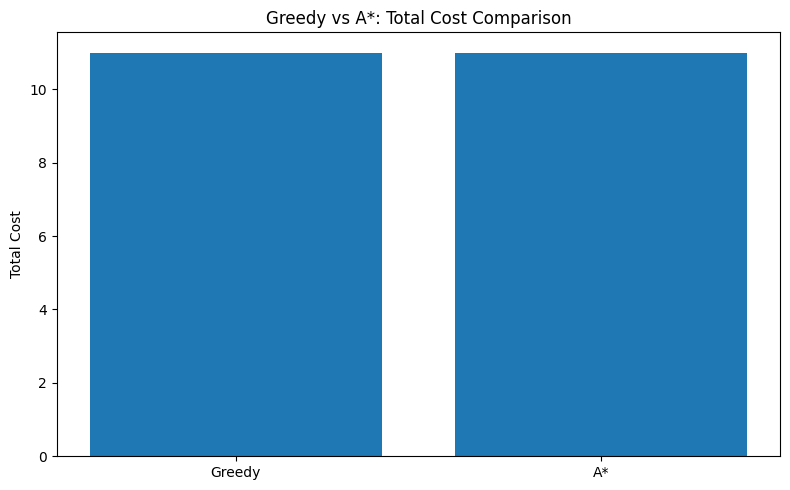

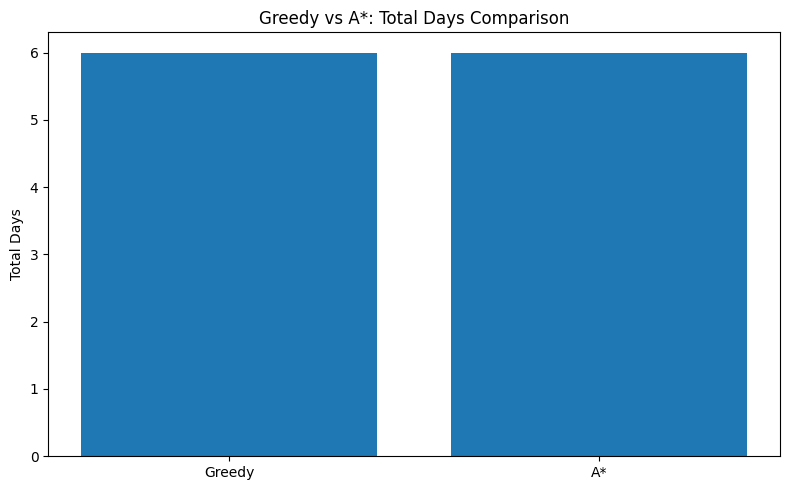

In [10]:
compare_df = pd.DataFrame({
    "Method": ["Greedy", "A*"],
    "Total Days": [greedy_total_days, astar_total_days],
    "Total Cost": [greedy_total_cost, astar_total_cost]
})

display(compare_df)

plt.figure(figsize=(8, 5))
plt.bar(compare_df["Method"], compare_df["Total Cost"])
plt.title("Greedy vs A*: Total Cost Comparison")
plt.ylabel("Total Cost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(compare_df["Method"], compare_df["Total Days"])
plt.title("Greedy vs A*: Total Days Comparison")
plt.ylabel("Total Days")
plt.tight_layout()
plt.show()

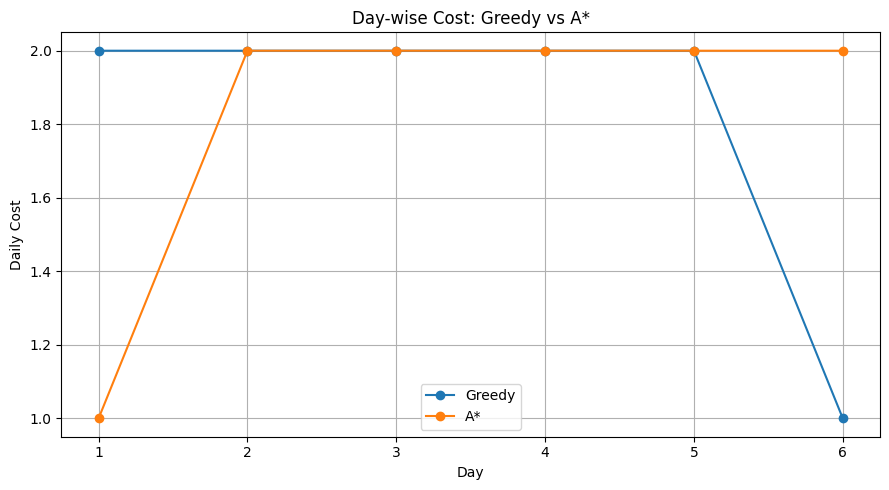

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(df_greedy["Day"], df_greedy["Daily_Cost"], marker='o', label="Greedy")
plt.plot(df_astar["Day"], df_astar["Daily_Cost"], marker='o', label="A*")
plt.title("Day-wise Cost: Greedy vs A*")
plt.xlabel("Day")
plt.ylabel("Daily Cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()